<a href="https://colab.research.google.com/github/ps-research/FinDex/blob/main/UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import umap
from sklearn.preprocessing import MultiLabelBinarizer
from sentence_transformers import SentenceTransformer
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# High-quality plot settings
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

DATASET_PATH = "/content/FinDex.json"
OUTPUT_DIR = "/content/"

# Create output directory
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Labels
INTENT_LABELS = [
    "Advocacy & Warning",
    "Community Building & Solidarity Seeking",
    "Emotional & Esteem Support-Seeking",
    "Informational Help-Seeking",
    "Instrumental Help-Seeking",
    "Sense-Making & Narrative Construction",
    "Venting / Catharsis"
]

IMPACT_LABELS = [
    "Behavioral Impact (Maladaptive Coping)",
    "Cognitive Impact",
    "Economic & Material Impact",
    "Physical Health Impact",
    "Psychological & Emotional Impact",
    "Relational & Social Impact"
]


INTENT_LABELS_SHORT = ["A&W", "CB&SS", "E&ESS", "IHS", "InHS", "SM&NC", "V/C"]
IMPACT_LABELS_SHORT = ["BI(MC)", "CI", "E&MI", "PHI", "P&EI", "R&SI"]

print(f"Configuration loaded")
print(f"Output directory: {OUTPUT_DIR}")

Configuration loaded
Output directory: /content/


In [3]:
# ============================================================================
# LOAD DATA
# ============================================================================

with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Loaded {len(data)} samples")

# Extract components
texts = [sample['text'] for sample in data]
intent_labels = [sample['labels']['intent'] for sample in data]
impact_labels = [sample['labels']['impact'] for sample in data]

# Multi-label encoding
intent_mlb = MultiLabelBinarizer(classes=INTENT_LABELS)
impact_mlb = MultiLabelBinarizer(classes=IMPACT_LABELS)

intent_encoded = intent_mlb.fit_transform(intent_labels)
impact_encoded = impact_mlb.fit_transform(impact_labels)

print(f"Intent shape: {intent_encoded.shape}")
print(f"Impact shape: {impact_encoded.shape}")

Loaded 2408 samples
Intent shape: (2408, 7)
Impact shape: (2408, 6)


In [4]:
def create_combined_umap_embedding(texts, intent_encoded, impact_encoded,
                                   intent_labels, impact_labels,
                                   intent_labels_short, impact_labels_short):
    """
    Create side-by-side UMAP visualizations for intent and impact.
    """
    print(f"Generating embeddings...")

    # Load sentence transformer
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    embeddings = model.encode(texts, show_progress_bar=True)

    print(f"Reducing dimensions with UMAP...")

    # Apply UMAP
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    embedding_2d = reducer.fit_transform(embeddings)

    # Create side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # ===== INTENT PLOT =====
    # Get dominant label for each sample
    dominant_labels_intent = []
    for sample_labels in intent_encoded:
        if sample_labels.sum() > 0:
            dominant_idx = np.argmax(sample_labels)
            dominant_labels_intent.append(intent_labels_short[dominant_idx])
        else:
            dominant_labels_intent.append('None')

    unique_labels_intent = list(set(dominant_labels_intent))
    if 'None' in unique_labels_intent:
        unique_labels_intent.remove('None')
    unique_labels_intent = sorted(unique_labels_intent)

    color_palette = plt.cm.get_cmap('tab10', len(unique_labels_intent))

    for idx, label in enumerate(unique_labels_intent):
        mask = np.array([l == label for l in dominant_labels_intent])
        ax1.scatter(embedding_2d[mask, 0],
                   embedding_2d[mask, 1],
                   label=label,
                   alpha=0.6,
                   s=40,
                   marker='o',
                   c=[color_palette(idx)])

    ax1.set_title('Semantic Clustering by Intent Labels', fontsize=16, fontweight='bold')
    ax1.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax1.set_ylabel('UMAP Dimension 2', fontsize=1)
    ax1.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax1.grid(True, alpha=0.3)

    # ===== IMPACT PLOT =====
    # Get dominant label for each sample
    dominant_labels_impact = []
    for sample_labels in impact_encoded:
        if sample_labels.sum() > 0:
            dominant_idx = np.argmax(sample_labels)
            dominant_labels_impact.append(impact_labels_short[dominant_idx])
        else:
            dominant_labels_impact.append('None')

    unique_labels_impact = list(set(dominant_labels_impact))
    if 'None' in unique_labels_impact:
        unique_labels_impact.remove('None')
    unique_labels_impact = sorted(unique_labels_impact)

    color_palette = plt.cm.get_cmap('Dark2', len(unique_labels_impact))

    for idx, label in enumerate(unique_labels_impact):
        mask = np.array([l == label for l in dominant_labels_impact])
        ax2.scatter(embedding_2d[mask, 0],
                   embedding_2d[mask, 1],
                   label=label,
                   alpha=0.6,
                   s=40,
                   marker='o',
                   c=[color_palette(idx)])

    ax2.set_title('Semantic Clustering by Impact Labels', fontsize=16, fontweight='bold')
    ax2.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax2.set_ylabel('UMAP Dimension 2', fontsize=12)
    ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    return fig

Generating embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Reducing dimensions with UMAP...
Saved: /content/fig2_umap_combined.pdf


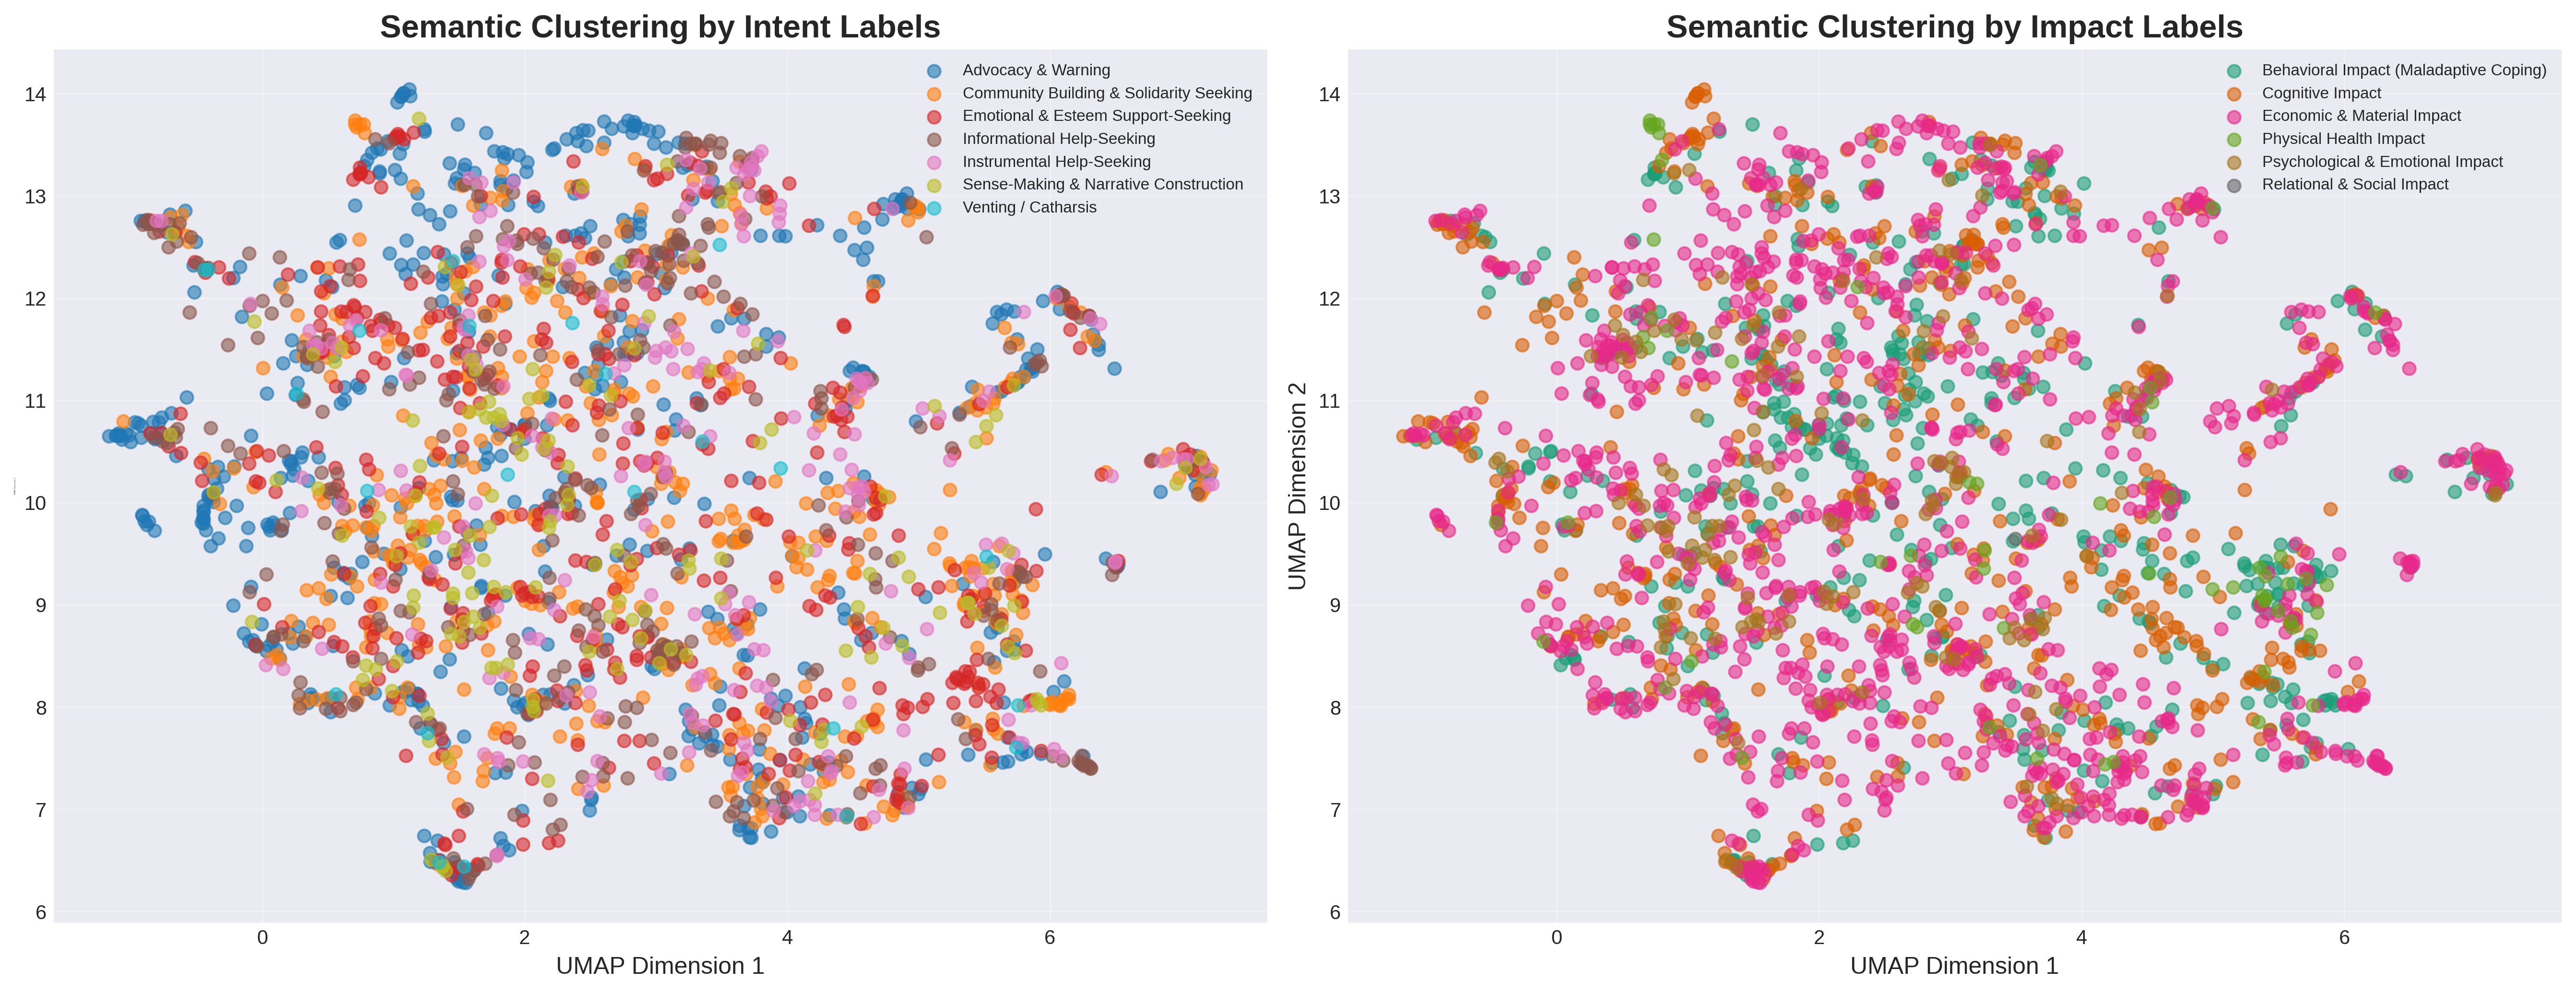

In [5]:
# Generate combined UMAP figure
fig = create_combined_umap_embedding(
    texts,
    intent_encoded,
    impact_encoded,
    INTENT_LABELS,
    IMPACT_LABELS,
    INTENT_LABELS,
    IMPACT_LABELS
)

# Save
output_path = os.path.join(OUTPUT_DIR, 'fig2_umap_combined.pdf')
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Saved: {output_path}")

plt.show()